# **Mission of clustering notebook**

You have joined a space-biology team studying how the model plant [*Arabidopsis thaliana*](https://en.wikipedia.org/wiki/Arabidopsis_thaliana) adapts to life aboard the [International Space Station](https://www.nasa.gov/international-space-station/). Your team is trying to find the [biological pathways](https://en.wikipedia.org/wiki/Biological_pathway) that plant roots use to respond to adverse conditions in space such as [microgravity](https://www.nasa.gov/centers-and-facilities/glenn/what-is-microgravity/) and altered light. Your data come from the **CARA experiment** (*Characterizing Arabidopsis Root Attractions*; Paul & Ferl) -- NASA OSDR dataset [**OSD-120 / GLDS-120**](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120). Seedling **roots** were grown on the ISS (**spaceflight, FLT**) and on the ground (**ground control, GC**), then sequenced to measure gene expression in the form of [RNA-seq](https://en.wikipedia.org/wiki/RNA-Seq).

Your mission is to use unsupervised machine learning - [clustering](https://en.wikipedia.org/wiki/Cluster_analysis) - to determine if the spaceflight root samples and their ground control counterparts have clearly distinguishable gene expression profiles. For if they do, then there is a chance that a supervised learning method can predict responses to spaceflight using different combinations and weights of gene expression from the RNA-seq data.

In this notebook, you will use k-means, PCA, and a heatmap to reach your conclusions.

# Set up the notebook

This notebook is self-contained: instead of relying on a shared methods module, we import the libraries we need and define a few small helper functions right here. We load the CARA (OSD-120) *Arabidopsis* root RNA-seq data directly from the [NASA Open Science Data Repository (OSDR)](https://osdr.nasa.gov/bio/) over the internet, so all you need is an internet connection.

In [1]:
# import the libraries we will use throughout this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from pydeseq2.dds import DeseqDataSet

import warnings
warnings.filterwarnings('ignore')

In [2]:
# the OSDR public download service: build a URL for any file in study OSD-120 (CARA)
OSDR_BASE = ("https://osdr.nasa.gov/geode-py/ws/studies/OSD-120/"
             "download?source=datamanager&file=")

def osdr_url(filename):
    return OSDR_BASE + filename

In [3]:
# helper functions for this notebook (replacing the old shared "methods" module)

def condition_from_sample(sample_name):
    """Return 'Space Flight' or 'Ground Control' from a CARA sample column name.

    Column names look like:
      Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13
    The 4th underscore-delimited field is 'FLT' (spaceflight) or 'GC' (ground control).
    """
    if "FLT" in sample_name:
        return "Space Flight"
    if "GC" in sample_name:
        return "Ground Control"
    return None

def filter_data(df, dropnans=False, droplowcvs=0):
    """Filter the genes (rows) of a genes-x-samples counts table.

    dropnans   : drop genes that have any NaN values.
    droplowcvs : keep only genes whose coefficient of variation (CV = std / mean
                 across samples) is greater than this threshold. Dropping low-CV
                 genes is a form of dimensionality reduction that removes
                 low-information genes so the clustering can focus on the signal.
    """
    if dropnans:
        df = df.dropna()
    if droplowcvs != 0:
        cv = df.std(axis=1) / df.mean(axis=1).replace(0, np.nan)
        # plot the distribution of coefficients of variation
        fig, axs = plt.subplots()
        axs.hist(cv.dropna(), bins=20)
        axs.set_xlabel('coefficient of variation')
        axs.set_ylabel('number of genes')
        df = df[cv > droplowcvs]
    return df

def my_kmeans(df, k):
    """Run k-means on the samples (columns) and print each sample's cluster."""
    X = df.T.to_numpy()                       # one row per sample, one column per gene
    kmeans = KMeans(n_clusters=k, random_state=42, init="k-means++").fit(X)
    for sample in df.columns:
        cluster = kmeans.predict([list(df[sample])])
        print('sample: ', sample, ', cluster: ', cluster, condition_from_sample(sample))

def find_k_elbow(df):
    """Plot within-cluster-sum-of-squares vs k (the elbow method)."""
    X = df.T.to_numpy()
    wcss = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=i)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)
    plt.scatter(range(1, 11), wcss)
    plt.xlabel('k')
    plt.ylabel('within-cluster sum of squares')

def my_gmm(df, k):
    """Fit a Gaussian mixture model on the samples and print each sample's cluster."""
    X = df.T.to_numpy()
    gm = GaussianMixture(n_components=k, random_state=42).fit(X)
    for sample in df.columns:
        cluster = gm.predict([list(df[sample])])
        print('sample: ', sample, ', cluster: ', cluster, condition_from_sample(sample))
    return gm

# read in data and metadata

The data that we will be using is [normalized](https://en.wikipedia.org/wiki/Normalization_(statistics)) RNA-seq data which was generated from the **roots of *Arabidopsis thaliana* seedlings** grown on the ISS. The counts of genes per sample are represented in a table and have been normalized, which means they've been changed to account for differences in how the RNA-seq experiment played out. For example, some transcripts may have been copied multiple times in the experiment (called [sequencing depth](https://www.biostars.org/p/282708/)) while others may not have been as deeply copied. Moreover, because some genes are much longer than others, longer genes will have more transcript fragments and appear to be more highly expressed than shorter genes. These differences will change the results of our analysis because we are looking for differences in gene expression (i.e. counts) between genes and between samples.
 Normalization is a statistical process of correcting for these differences, and there are many methods available. The goal of normalization is to make the gene expression profiles more comparable across samples, allowing for accurate comparisons and statistical analysis.

In [4]:
# read in the normalized RNA-seq data from OSD-120 (CARA Arabidopsis roots)
data = dict()
metadata = dict()

# normalized counts: genes (AGI loci, e.g. AT1G01010) are rows, root samples are columns
data['120-normalized'] = pd.read_csv(
    osdr_url('GLDS-120_rna_seq_Normalized_Counts_GLbulkRNAseq.csv'), index_col=0)

# the sample condition table (one row per sample, with a 'condition' column)
metadata['120'] = pd.read_csv(
    osdr_url('GLDS-120_rna_seq_SampleTable_GLbulkRNAseq.csv'), index_col=0)

In [5]:
# display the dimensions of the RNA-seq data set and the associated metadata
print('data shape: ', data['120-normalized'].shape)
print('metadata shape: ', metadata['120'].shape)

data shape:  (24740, 36)
metadata shape:  (36, 1)


# Use the K-means algorithm to cluster the RNA-seq data

In [6]:
# create a copy of the normalized RNA-seq data from OSD-120
df = data['120-normalized']

In [7]:
# filter out nans (and view the distribution of coefficients of variation)
print('before filter: ', df.shape)
df = filter_data(df, dropnans=True, droplowcvs=0)
print('after filter: ', df.shape)

before filter:  (24740, 36)
after filter:  (24740, 36)


In [8]:
# run the my_kmeans method with k=2
my_kmeans(df, k=2)

sample:  Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep3_GSM2493770_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_dark_Re

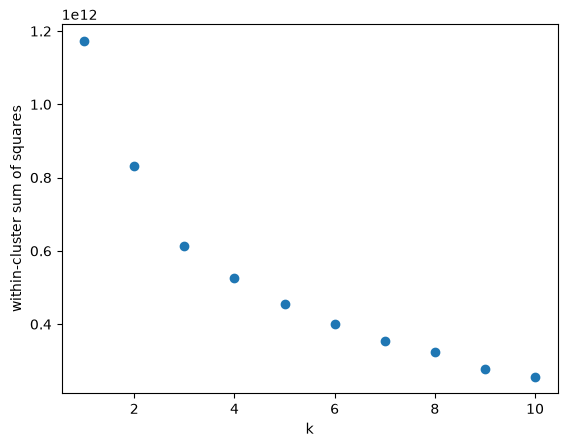

In [9]:
find_k_elbow(df)

In [10]:
# now build kmeans with k=elbow
my_kmeans(df, k=3)

sample:  Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13 , cluster:  [2] Ground Control
sample:  Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13 , cluster:  [2] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13 , cluster:  [2] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13 , cluster:  [2] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13 , cluster:  [2] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep3_GSM2493770_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_dark_Re

In [11]:
# two Col-0 spaceflight replicates can look like they are pulling away from the rest.
# Try removing them and re-running k-means to see how cluster membership changes.
outliers = ['Atha_Col-0_root_FLT_Alight_Rep2_GSM2493778_Day13',
            'Atha_Col-0_root_FLT_Alight_Rep3_GSM2493779_Day13']
for sample in df.columns:
  print(sample)
for sample in outliers:
  if sample in df.columns:
    df = df.drop(columns=[sample], inplace=False)
my_kmeans(df, k=3)

Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13
Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13
Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13
Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13
Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13
Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13
Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13
Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13
Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13
Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13
Atha_Col-0_root_GC_dark_Rep3_GSM2493770_Day13
Atha_Ws_root_GC_dark_Rep1_GSM2493771_Day13
Atha_Ws_root_GC_dark_Rep2_GSM2493772_Day13
Atha_Ws_root_GC_dark_Rep3_GSM2493773_Day13
Atha_Col-0-PhyD_root_GC_dark_Rep1_GSM2493774_Day13
Atha_Col-0-PhyD_root_GC_dark_Rep2_GSM2493775_Day13
Atha_Col-0-PhyD_root_GC_dark_Rep3_GSM2493776_Day13
Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day13
Atha_Col-0_root_FLT_Alight_Rep2_GSM2493778_Day13
Atha_Col-0_root_FLT_Alight_Rep3_GSM2493779_Day13
Atha_Ws_root_FLT_Alight_Rep1_GSM2493780_Day

sample:  Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13 , cluster:  [1] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13 , cluster:  [1] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13 , cluster:  [2] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep3_GSM2493770_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_dark_Rep1_GSM2493771_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_dark_Rep2_GSM2493772_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_dark_Rep3_GSM2493773_Day13 , cluster:  [2] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_dark_Rep1_G

sample:  Atha_Col-0-PhyD_root_FLT_Alight_Rep1_GSM2493783_Day13 , cluster:  [1] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_Alight_Rep2_GSM2493784_Day13 , cluster:  [1] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_Alight_Rep3_GSM2493785_Day13 , cluster:  [1] Space Flight
sample:  Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13 , cluster:  [1] Space Flight
sample:  Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13 , cluster:  [0] Space Flight


sample:  Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13 , cluster:  [0] Space Flight
sample:  Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13 , cluster:  [2] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13 , cluster:  [1] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13 , cluster:  [2] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13 , cluster:  [2] Space Flight
sample:  Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13 , cluster:  [1] Ground Control


It looks like the gene expression of the ground control samples tends to cluster together, separate from the spaceflight samples. This supports our suspicion that the two removed Col-0 spaceflight replicates were behaving like outliers, but it's difficult to tell by just looking at cluster membership. What we need is a visual way to view how the samples cluster and separate between ground control and spaceflight. For that we turn to PCA clustering.

**QUESTIONS**

1. Using the histogram of CVs, about how many genes have a CV of 0.5 or less?

2. After removing the 2 Col-0 spaceflight outliers and re-running k-means, does any other sample seem to be clustering with the "wrong" group? Which one?

3. Given these results, would you say that spaceflight and ground control samples have distinct gene expression profiles?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

# Use PCA to cluster and plot the RNA-seq data

Let's use the PCA clustering technique so we can visualize the data in 2-dimensions to see how spaceflight and ground control samples cluster and separate.

In [12]:
# initialize df
df = data['120-normalized']

In [13]:
# transpose the dataframe in preparation for PCA (one row per sample, one column per gene)
print('shape before transpose: ', df.shape)
X = df.to_numpy().T
print('shape after transpose: ', X.shape)

shape before transpose:  (24740, 36)
shape after transpose:  (36, 24740)


explained variance fraction (first two components): [0.44113202 0.26917492]


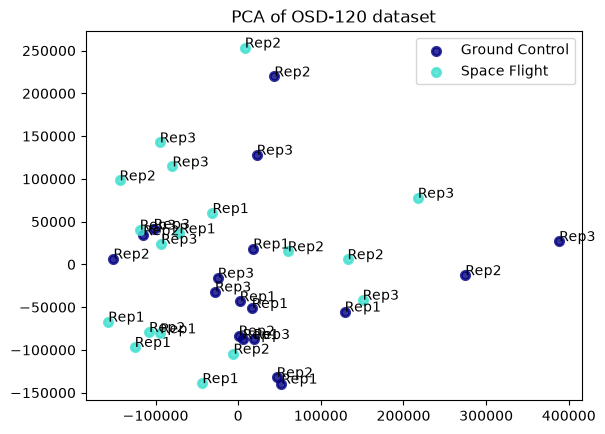

In [14]:
# create an array y that represents whether each sample is ground control or spaceflight
y = np.array([condition_from_sample(s) for s in df.columns])
target_names = np.array(['Ground Control', 'Space Flight'])

# run PCA to reduce dimensions from ~24,740 genes to 2!
pca = PCA(n_components=2)
X_r = pca.fit_transform(X)

# Percentage of variance explained by each component
print(
    "explained variance fraction (first two components): %s"
    % str(pca.explained_variance_ratio_)
)

# plot the pca plot
plt.figure()
colors = ["navy", "turquoise"]
lw = 2
for color, i, target_name in zip(colors, ['Ground Control', 'Space Flight'], target_names):
    plt.scatter(X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name)
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("PCA of OSD-120 dataset")

# label each point with its replicate (last field before the GSM/Day suffix)
samples = list(df.columns)
for i, txt in enumerate(samples):
    plt.annotate(txt.split('_')[5], (X_r[i][0], X_r[i][1]))
plt.show()

We might choose to eliminate any outliers from both spaceflight and ground control for downstream analysis. But we are already low on data, so removing data points is expensive. And actually, we're not using the PCA plot for modeling the data and making predictions so there's no real concept of accuracy or performance. Instead, we're using it to get a visual representation of the distribution of the data. Now we see how the ground control and space flight samples cluster together except for a few outliers.

**QUESTIONS**

1. Which samples are the outlier space flight samples?

2. Which samples are the outlier ground control samples?

3. Do these PCA clusters corroborate what we found using K-means in terms of data separation and outliers?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

# Use the DESeq2 implementation of PCA

[DESeq2](https://www.bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html) is a software implementation that performs [differential gene expression analysis](https://en.wikipedia.org/wiki/Gene_expression_profiling) to identify which genes are differentially expressed (highly up-regulated or down-regulated) relative to other genes in the expression profile.  This tool is used to identify which genes may be responsible for a particular phenotype.  

In addition to performing differential gene expression analysis, DESeq2 also has an implementation of PCA.  This section of the notebook explores using it to compare against the `pydeseq2` implementation results.

In [15]:
# read in data
df = data['120-normalized']

In [16]:
dfT = df.T
dfT = dfT.reset_index().rename(columns={"index": "sample"})
dfT.columns.name = None

In [17]:
dfT.shape

(36, 24741)

In [18]:
condition_dict = dict()
for sample in list(dfT['sample']):
    val = condition_from_sample(sample)
    if val == 'Ground Control':
        condition_dict[sample] = 0
    else:
        condition_dict[sample] = 1
dfT["condition"] = dfT["sample"].map(condition_dict)
conditions = dfT[['sample', 'condition']]

In [19]:
counts = dfT.drop(columns=['sample', 'condition']).reset_index(drop=True)
counts = counts.astype(int)

In [20]:
dds = DeseqDataSet(counts=counts, metadata=conditions, design_factors="condition")
dds.deseq2()

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 11.63 seconds.

Fitting dispersion trend curve...


... done in 0.83 seconds.

Fitting MAP dispersions...


...

... done in 6.79 seconds.

Calculating cook's distance...
... done in 0.09 seconds.

Replacing 584 outlier genes.



Fitting dispersions...


... done in 0.30 seconds.

Fitting MAP dispersions...


... done in 0.28 seconds.

Fitting LFCs...


... done in 0.26 seconds.



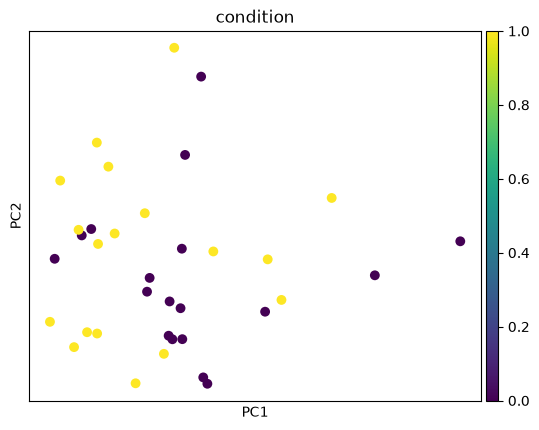

In [21]:
sc.tl.pca(dds)
sc.pl.pca(dds, color='condition', size=200)

**QUESTIONS**

1. What is the shape of the dataframe used as input to count the gene expression?  

2. How and why is this different than the shape of the original RNA-seq dataframe?

3. Do the 2 PCA plots agree in their distribution in 2 dimensions?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

# Use Gaussian mixture model to cluster the RNA-seq data


In [22]:
# read in data
df = data['120-normalized']

shape before filter:  (24740, 36)
shape after filter:  (3903, 36)


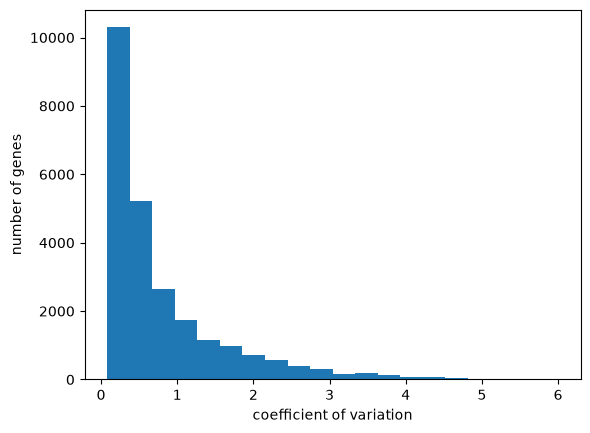

In [23]:
# filter data: keep only genes with a high coefficient of variation
print('shape before filter: ', df.shape)
df = filter_data(df, dropnans=True, droplowcvs=1.5)
print('shape after filter: ', df.shape)

In [24]:
# build gmm with 3 distributions (this may take several minutes with lots of data)
gmm = my_gmm(df, 3)

sample:  Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13 , cluster:  [2] Ground Control


sample:  Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13 , cluster:  [2] Ground Control


sample:  Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_GC_dark_Rep3_GSM2493770_Day13 , cluster:  [0] Ground Control


sample:  Atha_Ws_root_GC_dark_Rep1_GSM2493771_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_dark_Rep2_GSM2493772_Day13 , cluster:  [0] Ground Control
sample:  Atha_Ws_root_GC_dark_Rep3_GSM2493773_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_dark_Rep1_GSM2493774_Day13 , cluster:  [1] Ground Control


sample:  Atha_Col-0-PhyD_root_GC_dark_Rep2_GSM2493775_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0-PhyD_root_GC_dark_Rep3_GSM2493776_Day13 , cluster:  [0] Ground Control
sample:  Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0_root_FLT_Alight_Rep2_GSM2493778_Day13 , cluster:  [0] Space Flight


sample:  Atha_Col-0_root_FLT_Alight_Rep3_GSM2493779_Day13 , cluster:  [0] Space Flight
sample:  Atha_Ws_root_FLT_Alight_Rep1_GSM2493780_Day13 , cluster:  [0] Space Flight
sample:  Atha_Ws_root_FLT_Alight_Rep2_GSM2493781_Day13 , cluster:  [0] Space Flight
sample:  Atha_Ws_root_FLT_Alight_Rep3_GSM2493782_Day13 , cluster:  [0] Space Flight


sample:  Atha_Col-0-PhyD_root_FLT_Alight_Rep1_GSM2493783_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_Alight_Rep2_GSM2493784_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_Alight_Rep3_GSM2493785_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13 , cluster:  [0] Space Flight


sample:  Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13 , cluster:  [0] Space Flight
sample:  Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13 , cluster:  [0] Space Flight
sample:  Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13 , cluster:  [0] Space Flight


sample:  Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13 , cluster:  [0] Space Flight
sample:  Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13 , cluster:  [0] Space Flight


sample:  Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13 , cluster:  [0] Ground Control


**QUESTIONS**

1. How many genes were dropped from the dataframe after dropping 1.5 or lower CVs?  What do you think the effect will be on the quality of the clustering after dropping so many genes from the data set?

2. Does the GMM algorithm require that you specify the number of clusters up-front, or does the algorithm find the ideal number for you?

3. Do the GMM cluster results resemble those of k-means?  Why or why not?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

# Plot the RNA-seq gene expression data in a heatmap

shape before filter:  (24740, 36)
shape after filter:  (3903, 36)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.



Fitting dispersions...


... done in 2.20 seconds.

Fitting dispersion trend curve...


... done in 0.30 seconds.

Fitting MAP dispersions...


...

... done in 1.96 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 606 outlier genes.



Fitting dispersions...


... done in 0.30 seconds.

Fitting MAP dispersions...


... done in 0.30 seconds.

Fitting LFCs...


... done in 0.33 seconds.



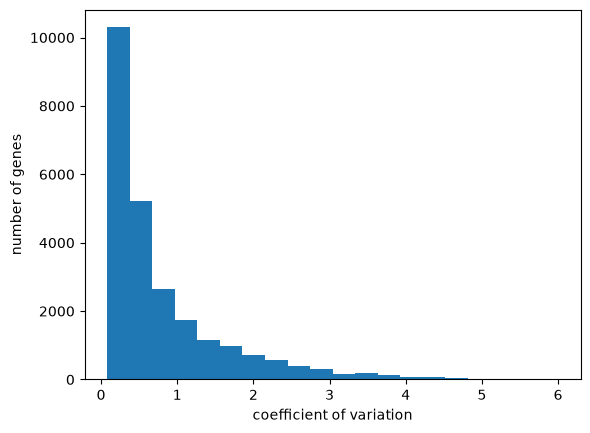

In [25]:
# read in data
df = data['120-normalized']

# filter data: drop NaNs and keep only high-CV (high-information) genes
print('shape before filter: ', df.shape)
df = filter_data(df, dropnans=True, droplowcvs=1.5)
print('shape after filter: ', df.shape)

# transpose the dataframe (one row per sample)
dfT = df.T
dfT = dfT.reset_index().rename(columns={"index": "sample"})
dfT.columns.name = None


# assign a "condition" to each sample as either 1 (space flight) or 0 (ground control)
condition_dict = dict()
for sample in list(dfT['sample']):
    val = condition_from_sample(sample)
    if val == 'Ground Control':
        condition_dict[sample] = 0
    else:
        condition_dict[sample] = 1
dfT["condition"] = dfT["sample"].map(condition_dict)
conditions = dfT[['sample', 'condition']]


# turn counts into integer values (normalized data is type float)
counts = dfT.drop(columns=['sample', 'condition']).reset_index(drop=True)
counts = counts.astype(int)

# run a DESeq2 experiment that finds differential gene expression between the 2 conditions
# note we are not doing differential gene expression analysis but need to run this to get a PCA plot
dds = DeseqDataSet(counts=counts, metadata=conditions, design_factors="condition")
dds.deseq2()

In [26]:
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])

In [27]:
grapher = pd.DataFrame(dds.layers['log1p'].T, index=dds.var_names, columns=list(conditions['sample']))
grapher.head()

,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01046,0.0,0.000000,0.000000,0.00000,2.122199,0.000000,0.144903,0.000000,0.0,0.000000,...,0.618618,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.782403
AT1G01150,0.0,2.405994,0.000000,0.14833,0.000000,0.000000,0.000000,0.000000,0.0,0.919740,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.917290,0.000000,0.000000,0.000000
AT1G01190,0.0,3.238793,0.000000,0.00000,0.904176,4.217297,0.075074,1.460937,0.0,3.096524,...,0.000000,2.859553,0.000000,0.0,0.0,1.584386,3.482854,1.565878,4.550816,3.423220
AT1G01305,0.0,1.356530,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,1.814526,0.000000,0.606148,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
AT1G01355,0.0,0.000000,2.295519,0.14833,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


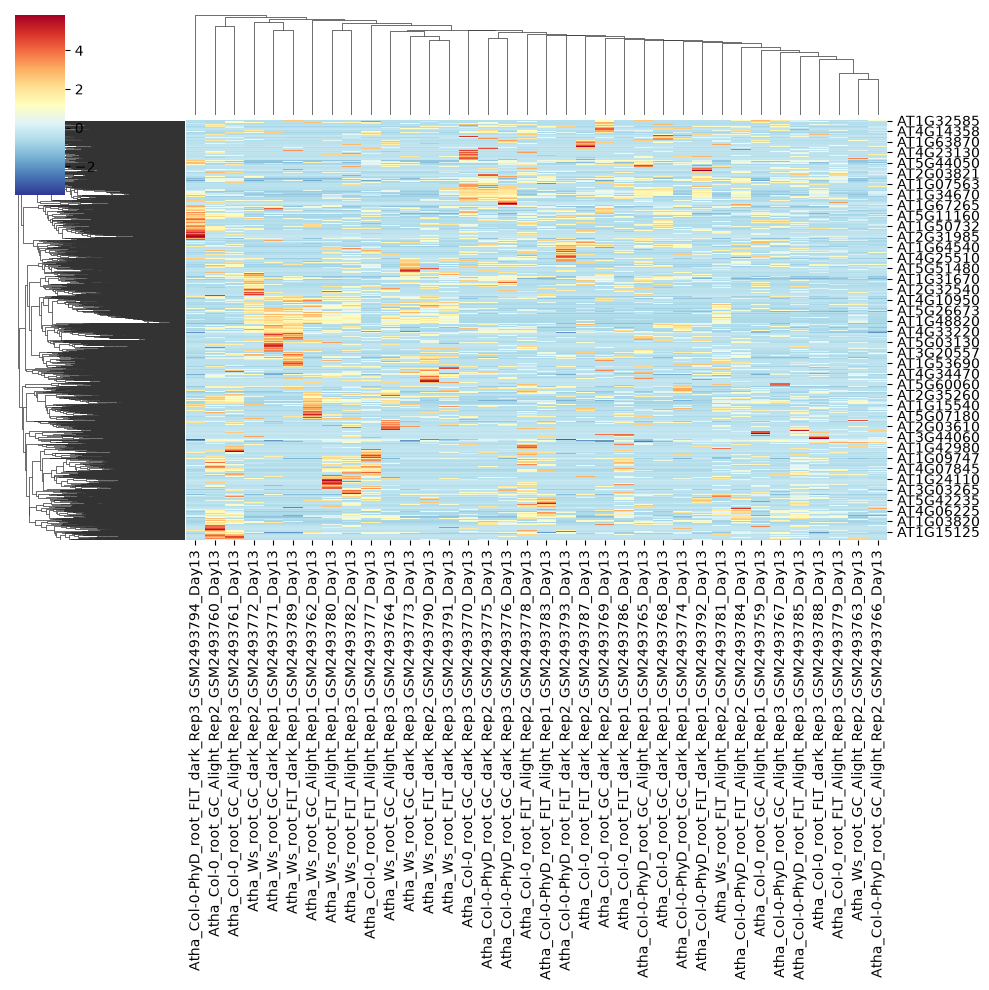

In [28]:
sns.clustermap(grapher, z_score=0, cmap='RdYlBu_r')

**QUESTIONS**

1.  On which axis do the samples appear, vertical or horizontal? The genes?

2.  Pick any one spaceflight root sample. Which 2 samples are least similar to it? How did you choose them?

3.  Which gene and sample have the hottest expression? The coldest?

**Double click here to enter your answers to the questions above.**

1.

2.

3.